In [1]:

# Mount Google Drive so we can access our project files.
# Files inside /content disappear when the Colab runtime resets,
# but files inside Google Drive are persistent.
from google.colab import drive
drive.mount('/content/drive')


# Import the libraries we need for this notebook.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Define the main project folder.
project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'


# Define the locations of our NASA spacecraft telemetry data.
data_path = project_path + '/data/raw/archive/data/data'

train_path = data_path + '/train'
test_path = data_path + '/test'


# The anomaly labels are stored separately from the .npy telemetry files.
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'


# Check that everything exists before we continue.
print("SERIAL 12 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))
print("Labels file exists:", os.path.exists(labels_path))

Mounted at /content/drive
SERIAL 12 loaded successfully.
Project folder exists: True
Train folder exists: True
Test folder exists: True
Labels file exists: True


In [2]:

# Load A-8 Telemetry


# We will start with spacecraft channel A-8.
# A-8 belongs to the SMAP spacecraft.
channel = "A-8"


# Load the A-8 test data from the NumPy (.npy) file.
# The test data contains the telemetry we want to analyze.
data_A8 = np.load(test_path + "/" + channel + ".npy")


# The first column contains the main telemetry signal.
# We extract that column and store it in 'telemetry_A8'.
telemetry_A8 = data_A8[:, 0]


# Display basic information about the loaded telemetry.
print("Channel:", channel)
print("Data shape:", data_A8.shape)
print("Telemetry shape:", telemetry_A8.shape)
print("First 10 telemetry values:")
print(telemetry_A8[:10])

Channel: A-8
Data shape: (8375, 25)
Telemetry shape: (8375,)
First 10 telemetry values:
[0.9392753 0.9392753 0.9392753 0.9392753 0.9392753 0.9392753 0.9392753
 0.9392753 0.9392753 0.9392753]


In [4]:
# Load Ground-Truth Anomaly Labels

# Read the CSV file containing the known anomaly information.
labels_df = pd.read_csv(labels_path)

# Find the row for our selected channel (A-8).
A8_info = labels_df[labels_df["chan_id"] == channel].iloc[0]

# Display the known anomaly information for A-8.
print("Channel:", A8_info["chan_id"])
print("Spacecraft:", A8_info["spacecraft"])
print("Anomaly sequence:", A8_info["anomaly_sequences"])
print("Anomaly class:", A8_info["class"])
print("Number of values:", A8_info["num_values"])

Channel: A-8
Spacecraft: SMAP
Anomaly sequence: [[4569, 8374]]
Anomaly class: [contextual]
Number of values: 8375


In [5]:
# Calculate Normal Behavior

# Load the A-8 training data.
# Training data is used to learn what normal behavior looks like.
train_A8 = np.load(train_path + "/" + channel + ".npy")

# Extract the first column, which contains the telemetry signal.
train_telemetry_A8 = train_A8[:, 0]

# Calculate the average normal telemetry value.
normal_mean = np.mean(train_telemetry_A8)

# Calculate how much the normal telemetry values vary.
normal_std = np.std(train_telemetry_A8)

print("Training telemetry shape:", train_telemetry_A8.shape)
print("Normal mean:", normal_mean)
print("Normal standard deviation:", normal_std)

Training telemetry shape: (762,)
Normal mean: -0.24666460299358714
Normal standard deviation: 0.9690446150925986


In [6]:
# Calculate Z-scores

# Calculate how far each test telemetry value is from
# the normal mean, measured in standard deviations.
z_scores_A8 = (telemetry_A8 - normal_mean) / normal_std

# Display the first 10 Z-scores.
print("First 10 Z-scores:")
print(z_scores_A8[:10])

# Show the minimum and maximum Z-score.
print("\nMinimum Z-score:", np.min(z_scores_A8))
print("Maximum Z-score:", np.max(z_scores_A8))

First 10 Z-scores:
[1.22382384 1.22382384 1.22382384 1.22382384 1.22382384 1.22382384
 1.22382384 1.22382384 1.22382384 1.22382384]

Minimum Z-score: -0.7774001168505814
Maximum Z-score: 1.2864883448884963


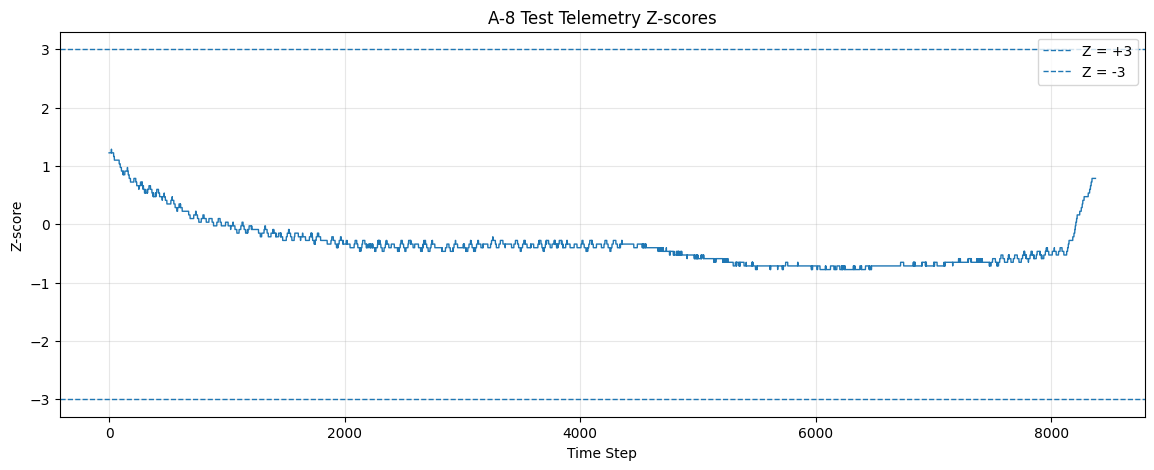

In [7]:
# Visualize Z-scores

# Create a figure for the Z-score sequence.
plt.figure(figsize=(14, 5))

# Plot the Z-score of every test telemetry point.
plt.plot(z_scores_A8, linewidth=1)

# Add reference lines at +3 and -3 standard deviations.
# These are commonly used as a simple statistical threshold.
plt.axhline(3, linestyle="--", linewidth=1, label="Z = +3")
plt.axhline(-3, linestyle="--", linewidth=1, label="Z = -3")

# Add labels to make the graph easy to understand.
plt.title("A-8 Test Telemetry Z-scores")
plt.xlabel("Time Step")
plt.ylabel("Z-score")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation of Global Z-score Detection

The global Z-score method was used as a statistical baseline to detect anomalies in the A-8 spacecraft telemetry. A threshold of ±3 standard deviations was used to identify unusually large deviations from the normal training behavior.

The results show that the Z-scores of the A-8 test telemetry remained between approximately -0.8 and +1.3. Therefore, none of the test points crossed the ±3 threshold.

However, the ground-truth anomaly begins around time step 4569. The anomalous behavior is therefore not detected by the global Z-score method.

This result demonstrates an important limitation of static global thresholding. The anomaly is contextual: the telemetry values change over time, but the values themselves are not extreme enough to exceed the global statistical threshold.

Therefore, more context-aware methods are needed for further investigation, such as rolling statistical methods, prediction-error methods, autoencoders, and LSTM-based models.


#github commit

In [8]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (16/16), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/11_feature_engineering.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/12_statistical_anomaly_detection.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [9]:
!git add notebooks/11_feature_engineering.ipynb notebooks/12_statistical_anomaly_detection.ipynb

In [10]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/11_feature_engineering.ipynb
	new file:   notebooks/12_statistical_anomaly_detection.ipynb



In [11]:
!git commit -m "Complete SERIAL 12 statistical anomaly detection"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9e874ce0df89.(none)')


In [12]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

In [13]:
!git config --global user.name
!git config --global user.email

Amit Chandra Das
arickroy0@gmail.com


In [14]:
!git commit -m "Complete SERIAL 12 statistical anomaly detection"

[main c0f1a32] Complete SERIAL 12 statistical anomaly detection
 2 files changed, 2 insertions(+), 1 deletion(-)
 create mode 100644 notebooks/12_statistical_anomaly_detection.ipynb


In [15]:
!git push origin main

Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 41.98 KiB | 2.10 MiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   f6beb90..c0f1a32  main -> main
